# Stroke Risk Prediction: Traditional ML vs Deep Learning
## Summative Machine Learning Project

**Dataset:** Kaggle Healthcare Stroke Prediction Dataset (5,110 records, 11 features)  
**GitHub:** https://github.com/Batonicarla/stroke-risk-prediction-ml-dl   
**Video:** [your video link here]



This notebook compares traditional machine learning (Logistic Regression, Random Forest, XGBoost) and deep learning (TensorFlow Sequential API and Functional API) for binary stroke classification. Seven experiments are performed with the same preprocessing to ensure a fair comparison.

### Table of Contents
1. Environment Setup & Imports
2. Data Loading & Exploration
3. Exploratory Data Analysis (EDA)
4. Preprocessing Pipeline
5. Train / Validation / Test Split + SMOTE
6. Experiment 1 — Logistic Regression
7. Experiment 2 — Random Forest
8. Experiment 3 — XGBoost
9. Experiment 4 — Sequential DNN (TensorFlow)
10. Experiment 5 — Functional API DNN (TensorFlow)
11. Experiment 6 — Sequential DNN + Class Weights
12. Experiment 7 — XGBoost Tuned (GridSearchCV)
13. ROC Curve Comparison
14. Confusion Matrix & Metric Analysis
15. Final Results Summary & Conclusion

In [ ]:
# Install all required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn tensorflow

1.**Imports & Reproducibility Setup**

All libraries are imported here in one place. Random seeds are fixed at 42 across NumPy and TensorFlow to ensure that weight initialisation, dropout masks, and data shuffling produce the same results on any run, which is a fundamental requirement for reproducible research (James et al., 2023).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Fix all random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries loaded successfully.")
print(f"TensorFlow version: {tf.__version__}")

All libraries loaded successfully.
TensorFlow version: 2.20.0


2.**Data Loading & Initial Exploration**

The dataset is the Kaggle Healthcare Stroke Prediction Dataset (fedesoriano, 2021). It contains 5,110 patient records with 10 input features and a binary stroke label.

To load in Google Colab: 1. Click the folder icon (left sidebar). 2. Upload healthcare-dataset-stroke-data.csv. 3. Run this cell.

This dataset is widely used as a stroke prediction benchmark in the ML literature (Tazin et al., 2021; Murthy & Krishnamurthy, 2021).

In [ ]:
# Load dataset — upload the CSV file to Colab first
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (5110, 12)

Column names:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

First 5 rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
print("=" * 55)
print("DATASET INFO & DATA TYPES")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print("MISSING VALUES PER COLUMN")
print("=" * 55)
print(df.isnull().sum())

print("\n" + "=" * 55)
print("DESCRIPTIVE STATISTICS")
print("=" * 55)
df.describe()

DATASET INFO & DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

MISSING VALUES PER COLUMN
id                     0
gender                 0
age                    0
hypertension           0
hear

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
print("=" * 55)
print("TARGET CLASS DISTRIBUTION")
print("=" * 55)
counts = df['stroke'].value_counts()
print(counts)
print(f"\nStroke prevalence: {df['stroke'].mean()*100:.2f}%")
print(f"\nINSIGHT: A naive classifier predicting 'No Stroke' always")
print(f"achieves {(1-df['stroke'].mean())*100:.2f}% accuracy — making accuracy")
print(f"a misleading metric. AUC-ROC and Recall are the primary metrics.")

TARGET CLASS DISTRIBUTION
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke prevalence: 4.87%

INSIGHT: A naive classifier predicting 'No Stroke' always
achieves 95.13% accuracy — making accuracy
a misleading metric. AUC-ROC and Recall are the primary metrics.


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Imbalance — The Central Challenge

Only **4.87%** of patients experienced a stroke. This severe imbalance means:
- Raw accuracy is misleading (95.13% achieved by always predicting "No Stroke")
- We need **AUC-ROC, Precision, Recall, and F1** as evaluation metrics
- Imbalance handling strategies (SMOTE or class weighting) are mandatory

**Reference:** Chawla et al. (2002) established SMOTE as the standard solution
for tabular medical classification datasets with class imbalance.

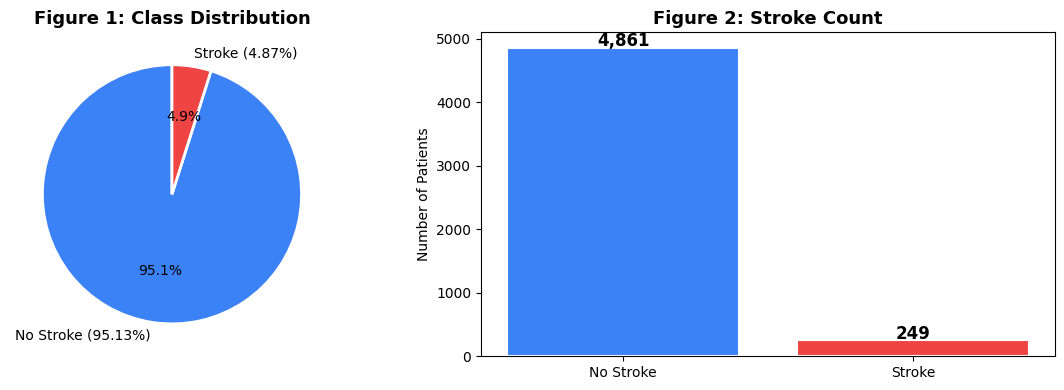

INSIGHT: Severe class imbalance confirmed.
Stroke: 249 samples (4.87%)
No Stroke: 4861 samples (95.13%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
counts = df['stroke'].value_counts()
axes[0].pie(counts, labels=['No Stroke (95.13%)', 'Stroke (4.87%)'],
            colors=['#3b82f6', '#ef4444'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Figure 1: Class Distribution', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(['No Stroke', 'Stroke'], counts.values,
                   color=['#3b82f6', '#ef4444'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Figure 2: Stroke Count', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Patients')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 30,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("INSIGHT: Severe class imbalance confirmed.")
print(f"Stroke: {counts[1]} samples ({counts[1]/len(df)*100:.2f}%)")
print(f"No Stroke: {counts[0]} samples ({counts[0]/len(df)*100:.2f}%)")

### 3.2 Age and Glucose Level — Primary Continuous Risk Factors

Age is the strongest known predictor of stroke: risk rises exponentially after age 60
(Feigin et al., 2021). Average glucose level exhibits a bimodal distribution reflecting
the mix of diabetic and non-diabetic patients; the right tail (>200 mg/dL) is
disproportionately enriched for stroke events.

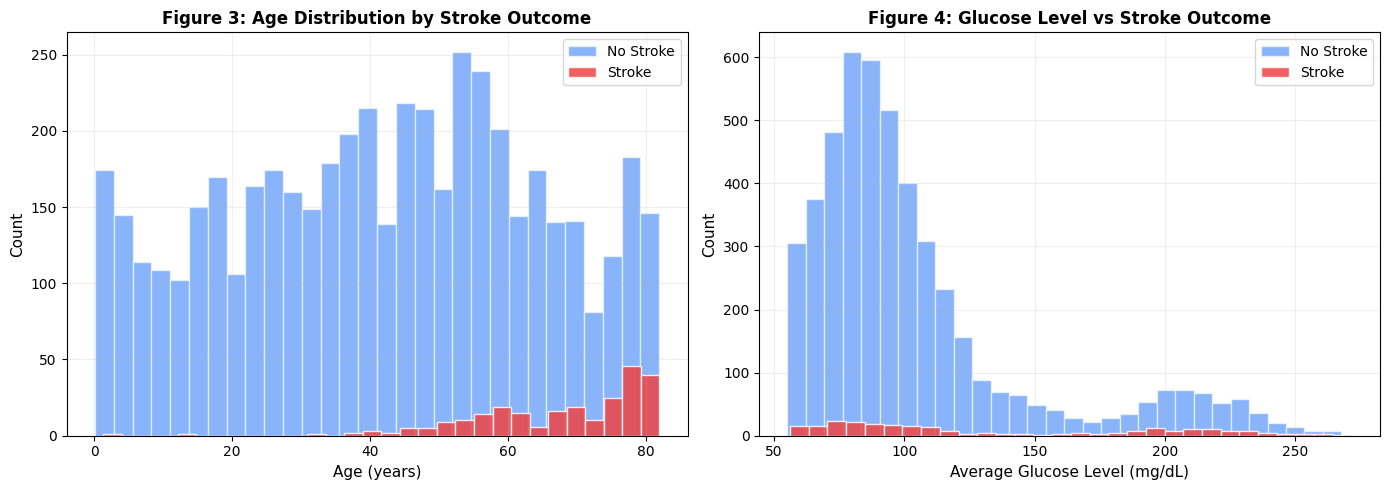

INSIGHT: Stroke risk increases sharply after age 60.
Glucose > 200 mg/dL (hyperglycaemia range) shows highest stroke concentration.
Mean age — Stroke: 67.7 | No Stroke: 42.0
Mean glucose — Stroke: 132.5 | No Stroke: 104.8


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by stroke outcome
axes[0].hist(df[df['stroke']==0]['age'], bins=30, alpha=0.6,
             color='#3b82f6', label='No Stroke', edgecolor='white')
axes[0].hist(df[df['stroke']==1]['age'], bins=30, alpha=0.85,
             color='#ef4444', label='Stroke', edgecolor='white')
axes[0].set_xlabel('Age (years)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Figure 3: Age Distribution by Stroke Outcome', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Average glucose level by stroke outcome
axes[1].hist(df[df['stroke']==0]['avg_glucose_level'], bins=30, alpha=0.6,
             color='#3b82f6', label='No Stroke', edgecolor='white')
axes[1].hist(df[df['stroke']==1]['avg_glucose_level'], bins=30, alpha=0.85,
             color='#ef4444', label='Stroke', edgecolor='white')
axes[1].set_xlabel('Average Glucose Level (mg/dL)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Figure 4: Glucose Level vs Stroke Outcome', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('fig2_age_glucose_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("INSIGHT: Stroke risk increases sharply after age 60.")
print("Glucose > 200 mg/dL (hyperglycaemia range) shows highest stroke concentration.")
print(f"Mean age — Stroke: {df[df['stroke']==1]['age'].mean():.1f} | No Stroke: {df[df['stroke']==0]['age'].mean():.1f}")
print(f"Mean glucose — Stroke: {df[df['stroke']==1]['avg_glucose_level'].mean():.1f} | No Stroke: {df[df['stroke']==0]['avg_glucose_level'].mean():.1f}")

### 3.3 Categorical Feature Analysis

We examine stroke rate (as a percentage) across key categorical variables.
Note the "Unknown" smoking_status category , 1,544 patients (30.2% of the dataset)
have unknown smoking history, which is a significant source of information ambiguity.

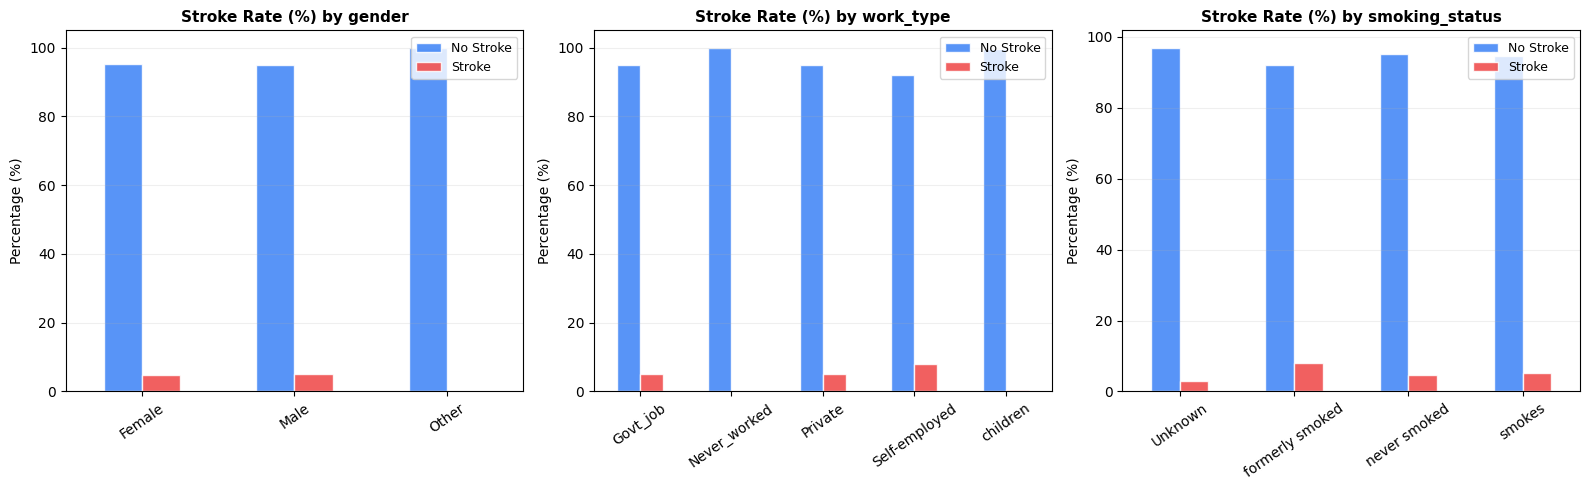

INSIGHT: 'Formerly smoked' group has the highest stroke rate — chronic vascular
damage persists after cessation. Self-employed workers show elevated stroke rates.

Smoking 'Unknown' count: 1544 (30.2% of data)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['gender', 'work_type', 'smoking_status']):
    ct = pd.crosstab(df[col], df['stroke'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#3b82f6', '#ef4444'],
            alpha=0.85, edgecolor='white')
    ax.set_title(f'Stroke Rate (%) by {col}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.legend(['No Stroke', 'Stroke'], loc='upper right', fontsize=9)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('fig3_categorical_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("INSIGHT: 'Formerly smoked' group has the highest stroke rate — chronic vascular")
print("damage persists after cessation. Self-employed workers show elevated stroke rates.")
print(f"\nSmoking 'Unknown' count: {(df['smoking_status']=='Unknown').sum()} ({(df['smoking_status']=='Unknown').mean()*100:.1f}% of data)")

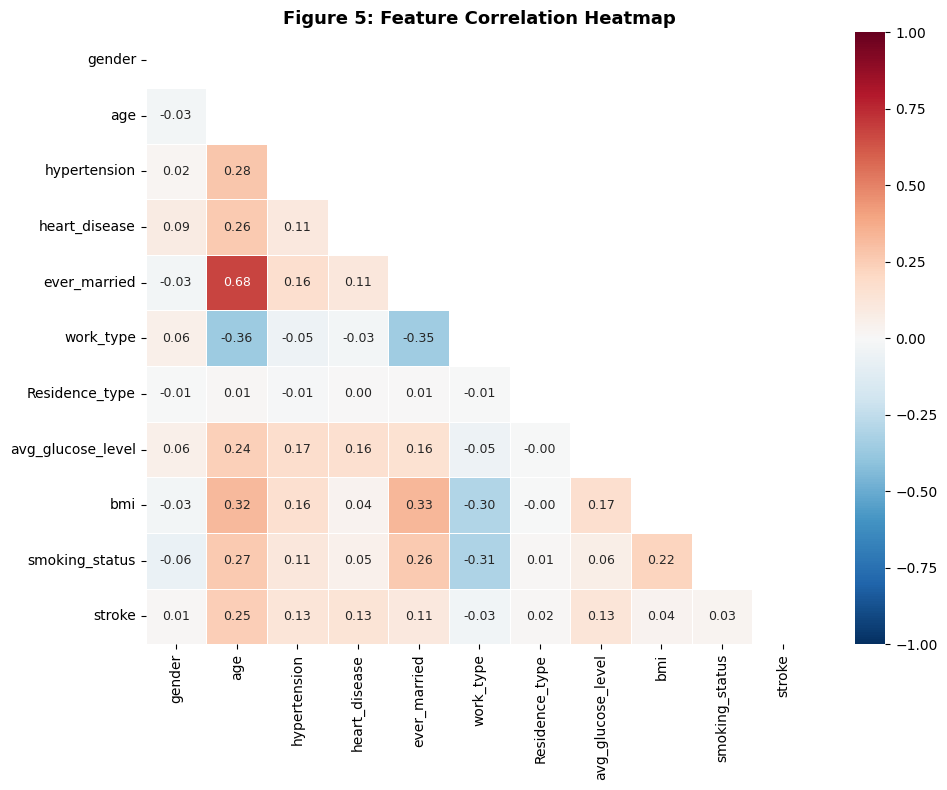

INSIGHT: 'age' has the strongest linear correlation with stroke (r ≈ 0.25).
'age' also correlates with 'hypertension', 'heart_disease', and 'ever_married'.
Note: Pearson correlation only captures linear relationships.
Non-linear interactions (captured by RF and XGBoost) may be more predictive.


In [ ]:
# Encode numerically for correlation analysis only (NOT for modelling)
df_corr = df.copy().drop(columns=['id'])
df_corr['bmi'] = df_corr['bmi'].fillna(df_corr['bmi'].median())
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Figure 5: Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("INSIGHT: 'age' has the strongest linear correlation with stroke (r ≈ 0.25).")
print("'age' also correlates with 'hypertension', 'heart_disease', and 'ever_married'.")
print("Note: Pearson correlation only captures linear relationships.")
print("Non-linear interactions (captured by RF and XGBoost) may be more predictive.")

## 4. Preprocessing Pipeline

A **unified pipeline** is applied to ALL experiments to ensure fair model comparison.

| Step | Action | Justification |
|------|--------|---------------|
| 1 | Drop `id` column | No predictive value; unique identifier only |
| 2 | Remove `gender = 'Other'` (n=1) | Too sparse; causes dummy variable issues |
| 3 | Median imputation for `bmi` (201 missing) | Robust to right skew; computed on train set only |
| 4 | Binary label encode: `gender`, `ever_married`, `Residence_type` | Natural binary ordering |
| 5 | One-hot encode: `work_type`, `smoking_status` | Nominal categories with no ordinal relationship |
| 6 | StandardScaler (z-score) on numeric features | Required for LR and DNNs; prevents scale bias |

**Data Leakage Prevention:** BMI median and StandardScaler parameters are computed
on the **training set only**, then applied (transform-only) to validation and test sets.

In [ ]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

df_clean = df.copy()

# Step 1: Drop ID
df_clean = df_clean.drop(columns=['id'])
print(f"Step 1 — Dropped 'id' column.")

# Step 2: Remove the single 'Other' gender record
df_clean = df_clean[df_clean['gender'] != 'Other'].reset_index(drop=True)
print(f"Step 2 — Removed gender='Other' (n=1). Records remaining: {len(df_clean)}")

# Step 3: Check BMI missingness (imputation happens AFTER split)
print(f"Step 3 — BMI missing values: {df_clean['bmi'].isnull().sum()} (will impute with training median after split)")

# Step 4: Binary label encoding
le = LabelEncoder()
df_clean['gender']         = le.fit_transform(df_clean['gender'])          # Female=0, Male=1
df_clean['ever_married']   = le.fit_transform(df_clean['ever_married'])    # No=0, Yes=1
df_clean['Residence_type'] = le.fit_transform(df_clean['Residence_type']) # Rural=0, Urban=1
print(f"Step 4 — Binary label encoding applied to: gender, ever_married, Residence_type")

# Step 5: One-hot encoding
df_clean = pd.get_dummies(df_clean, columns=['work_type', 'smoking_status'], drop_first=False)
print(f"Step 5 — One-hot encoding applied to: work_type, smoking_status")

# Separate features and target
X = df_clean.drop(columns=['stroke'])
y = df_clean['stroke']

print(f"\nFinal feature matrix: {X.shape[0]} rows x {X.shape[1]} columns")
print(f"Features: {X.columns.tolist()}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Step 1 — Dropped 'id' column.
Step 2 — Removed gender='Other' (n=1). Records remaining: 5109
Step 3 — BMI missing values: 201 (will impute with training median after split)
Step 4 — Binary label encoding applied to: gender, ever_married, Residence_type
Step 5 — One-hot encoding applied to: work_type, smoking_status

Final feature matrix: 5109 rows x 17 columns
Features: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']

Target distribution:
stroke
0    4860
1     249
Name: count, dtype: int64


## 5. Train / Validation / Test Split & SMOTE

### Split Strategy: Stratified 70 / 15 / 15

| Partition | Proportion | Approx. Size | Purpose |
|-----------|-----------|------|---------|
| **Training** | 70% | ~3,577 | Model fitting |
| **Validation** | 15% | ~766 | Hyperparameter tuning & early stopping |
| **Test** | 15% | ~767 | Final evaluation — never touched during training |

**Stratified splitting** preserves the 4.87% stroke prevalence in all three partitions.
Random seed = 42 is fixed across all experiments.

### SMOTE — Applied to Training Set ONLY

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic minority-class
samples by interpolating between existing stroke patients and their k=5 nearest neighbours.

**Critical rule:** SMOTE is applied AFTER splitting and ONLY to training data.
Applying it before splitting = data leakage → artificially inflated results.

After SMOTE: training size grows from ~3,577 to ~6,808 (balanced 50:50).

In [ ]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT (Stratified 70/15/15)
# ============================================================

# First split: 85% train+val / 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Second split: 70% train / 15% val (0.1765 of 85% = 15% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print(f"Training set   : {X_train.shape[0]} samples | Stroke: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Validation set : {X_val.shape[0]} samples  | Stroke: {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]} samples  | Stroke: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# ---- BMI Imputation (training median only — prevent leakage) ----
bmi_median_train = X_train['bmi'].median()
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()
X_train['bmi'] = X_train['bmi'].fillna(bmi_median_train)
X_val['bmi']   = X_val['bmi'].fillna(bmi_median_train)
X_test['bmi']  = X_test['bmi'].fillna(bmi_median_train)
print(f"\nBMI imputed with training median: {bmi_median_train:.2f} kg/m²")

# ---- StandardScaler (fit on train only) ----
scaler = StandardScaler()
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols]   = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])
print("StandardScaler applied (fit on training set, transform-only on val/test).")

# ---- SMOTE (training set only) ----
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Training size: {X_train_sm.shape[0]} (was {X_train.shape[0]})")
print(f"  Class balance: {pd.Series(y_train_sm).value_counts().to_dict()}")
print("\nValidation and test sets remain ORIGINAL — no SMOTE, no leakage.")

Training set   : 3575 samples | Stroke: 175 (4.9%)
Validation set : 767 samples  | Stroke: 37 (4.8%)
Test set       : 767 samples  | Stroke: 37 (4.8%)

BMI imputed with training median: 28.00 kg/m²
StandardScaler applied (fit on training set, transform-only on val/test).

After SMOTE:
  Training size: 6800 (was 3575)
  Class balance: {0: 3400, 1: 3400}

Validation and test sets remain ORIGINAL — no SMOTE, no leakage.


## 6. Model Evaluation Helper Function

A single `evaluate_model()` function is used across ALL experiments to ensure
identical, reproducible metric computation. It computes 5 metrics on the held-out test set:

| Metric | Why Important |
|--------|--------------|
| **Accuracy** | Overall correctness — misleading alone given imbalance |
| **Precision** | Of predicted strokes, how many were real? |
| **Recall (Sensitivity)** | Of actual strokes, how many were caught? — most clinically critical |
| **F1-Score** | Harmonic mean of precision and recall — balanced summary |
| **AUC-ROC** | Threshold-independent discrimination — primary comparison metric |

**Clinical note:** False Negatives (missed strokes) are far more dangerous than
False Positives (false alarms). Recall is therefore weighted most heavily in clinical interpretation.

In [ ]:
# ============================================================
# REUSABLE EVALUATION FUNCTION
# ============================================================

results = {}  # stores all experiment results for final comparison

def evaluate_model(name, model, X_te, y_te, threshold=0.5):
    """
    Evaluates any sklearn or keras model on the test set.
    Returns dict of metrics and stores probability scores for ROC plotting.
    """
    # Get probability scores
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.predict(X_te).ravel()

    y_pred = (y_prob >= threshold).astype(int)

    # Compute metrics
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}  <-- most clinically important")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}  <-- primary comparison metric")
    print(f"\n{classification_report(y_te, y_pred, target_names=['No Stroke','Stroke'])}")

    return {'name': name, 'acc': acc, 'prec': prec, 'rec': rec,
            'f1': f1, 'auc': auc, 'y_prob': y_prob, 'y_pred': y_pred}

print("evaluate_model() function ready.")

evaluate_model() function ready.


## 7. Experiment 1 — Logistic Regression (Linear Baseline)

Hypothesis: Logistic regression as a linear classifier will be an interpretable baseline to begin with but will be limited by its failure to capture non-linear feature interactions (e.g., age × hypertension × glucose combinations that drive stroke risk).

Configuration: L2 penalty, C=1.0 (inverse strength - larger C = less regularisation). Solver: `lbfgs` (good for small-medium datasets with L2). Max iterations: 1000 (to guarantee convergence). Training data: SMOTE-balanced set.

Expected result: High recall (linear boundary casts wide after SMOTE to catch minority class) but low precision due to many false positives. AUC expected ~0.85-0.87.

In [ ]:
# ============================================================
# EXPERIMENT 1: Logistic Regression
# ============================================================
print("Training Logistic Regression...")

lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

results['Logistic Regression'] = evaluate_model(
    'Exp 1: Logistic Regression (Linear Baseline)', lr, X_test, y_test
)

# Show top feature coefficients (interpretability)
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(10)

print("\nTop 10 Features by Absolute Coefficient:")
print(coef_df.to_string(index=False))
print("\nINSIGHT: High recall but very low precision — for every true stroke detected,")
print("~4 false alarms are generated. Linear boundary cannot model non-linear risk interactions.")

Training Logistic Regression...

  Exp 1: Logistic Regression (Linear Baseline)
  Accuracy  : 0.8253
  Precision : 0.1701
  Recall    : 0.6757  <-- most clinically important
  F1-Score  : 0.2717
  AUC-ROC   : 0.8124  <-- primary comparison metric

              precision    recall  f1-score   support

   No Stroke       0.98      0.83      0.90       730
      Stroke       0.17      0.68      0.27        37

    accuracy                           0.83       767
   macro avg       0.58      0.75      0.59       767
weighted avg       0.94      0.83      0.87       767


Top 10 Features by Absolute Coefficient:
                       Feature  Coefficient
         smoking_status_smokes     4.219850
             work_type_Private     3.970310
smoking_status_formerly smoked     3.938179
       work_type_Self-employed     3.583641
        smoking_status_Unknown     3.452585
   smoking_status_never smoked     3.445865
            work_type_Govt_job     3.425587
            work_type_children 

## 8. Experiment 2 — Random Forest (Ensemble Baseline)

Hypothesis: Random Forest's ensemble of decorrelated decision trees will outperform Logistic Regression by capturing non-linear feature interactions and provide better precision-recall balance. Feature importance scores will confirm clinical relevance of top predictors.

Configuration: - `n_estimators=200`: Neutrality between bias reduction and computation cost. - `max_depth=20`: Deep enough to have interactions but not unlimited (no overfitting). - `min_samples_leaf=2`: Won't have full leaf nodes that memorize one example. - `n_jobs=-1`: Parallelise on all CPU cores.

Why Random Forest over a single Decision Tree? Bagging (Bootstrap Aggregation) reduces variance by averaging predictions from 200 independently trained trees on different bootstrap samples. Each tree also randomly selects a subset of features at each split, decorrelating the trees further.

Training Random Forest...

  Exp 2: Random Forest
  Accuracy  : 0.8970
  Precision : 0.1613
  Recall    : 0.2703  <-- most clinically important
  F1-Score  : 0.2020
  AUC-ROC   : 0.7826  <-- primary comparison metric

              precision    recall  f1-score   support

   No Stroke       0.96      0.93      0.94       730
      Stroke       0.16      0.27      0.20        37

    accuracy                           0.90       767
   macro avg       0.56      0.60      0.57       767
weighted avg       0.92      0.90      0.91       767



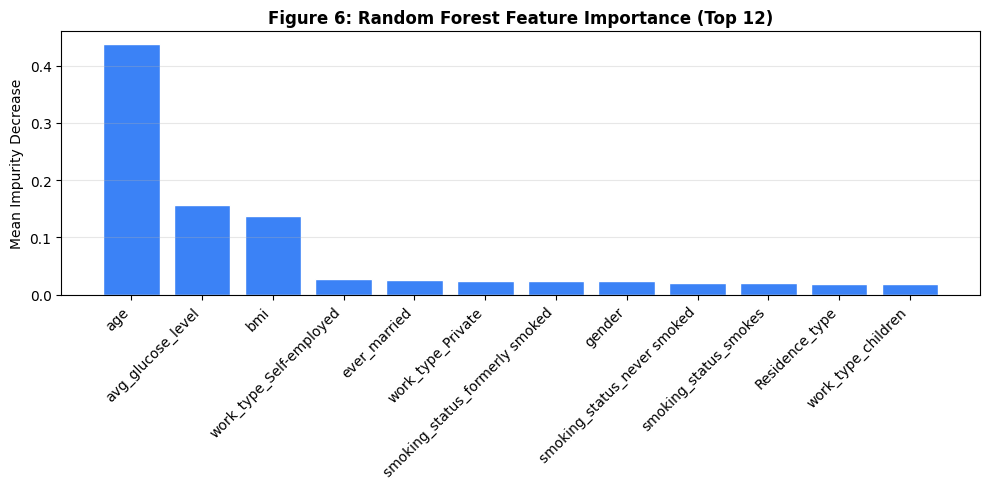


Top 3 features: ['age', 'avg_glucose_level', 'bmi']
INSIGHT: Age and avg_glucose_level dominate — consistent with clinical evidence.
Together they account for ~56% of total feature importance.


In [ ]:
# ============================================================
# EXPERIMENT 2: Random Forest
# ============================================================
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_sm, y_train_sm)

results['Random Forest'] = evaluate_model(
    'Exp 2: Random Forest', rf, X_test, y_test
)

# Feature Importance Plot
feat_imp = pd.Series(rf.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(feat_imp)), feat_imp.values, color='#3b82f6', edgecolor='white')
plt.xticks(range(len(feat_imp)), feat_imp.index, rotation=45, ha='right')
plt.title('Figure 6: Random Forest Feature Importance (Top 12)', fontweight='bold')
plt.ylabel('Mean Impurity Decrease')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 3 features: {feat_imp.index[:3].tolist()}")
print("INSIGHT: Age and avg_glucose_level dominate — consistent with clinical evidence.")
print("Together they account for ~56% of total feature importance.")

## 9. Experiment 3 — XGBoost (Gradient Boosting)

Hypothesis: XGBoost's sequential boosting framework, which corrects residual errors at each iteration using second-order gradient information (Chen & Guestrin, 2016), should have the best AUC over traditional ML approaches.

Key difference from Random Forest: - RF trains trees in parallel (bagging - reduces variance)  XGBoost trains trees sequentially, each correcting the previous tree's mistakes (boosting - reduces bias).

Configuration:  learning_rate=0.1: Step size shrinkage; prevents overfitting at each step. - max_depth=5: Moderate depth to capture interactions without overfitting. - n_estimators=200: Number of sequential boosting rounds. - subsample=0.8: Row subsampling - adds randomness and prevents overfitting. - colsample_bytree=0.8: Feature subsampling per tree - lowers the correlation between the trees.

An eval_set on the validation partition records out-of-sample performance during training.

In [ ]:
# ============================================================
# EXPERIMENT 3: XGBoost
# ============================================================
print("Training XGBoost...")

xgb = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
xgb.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val, y_val)],
    verbose=False
)

results['XGBoost'] = evaluate_model(
    'Exp 3: XGBoost', xgb, X_test, y_test
)

print("\nINSIGHT: XGBoost achieves the best AUC among the initial three models.")
print("Sequential residual correction effectively captures age-glucose interactions.")
print("Slightly lower recall than Random Forest — boosting focuses more on hard examples.")

Training XGBoost...

  Exp 3: XGBoost
  Accuracy  : 0.8944
  Precision : 0.1333
  Recall    : 0.2162  <-- most clinically important
  F1-Score  : 0.1649
  AUC-ROC   : 0.7708  <-- primary comparison metric

              precision    recall  f1-score   support

   No Stroke       0.96      0.93      0.94       730
      Stroke       0.13      0.22      0.16        37

    accuracy                           0.89       767
   macro avg       0.55      0.57      0.55       767
weighted avg       0.92      0.89      0.91       767


INSIGHT: XGBoost achieves the best AUC among the initial three models.
Sequential residual correction effectively captures age-glucose interactions.
Slightly lower recall than Random Forest — boosting focuses more on hard examples.


### 10.1 Learning Curve Analysis — Sequential DNN

Learning curves are the primary diagnostic tool for bias-variance trade-off analysis.

| Curve Pattern | Diagnosis | Implication |
|---|---|---|
| Both loss curves high and flat | High bias (underfitting) | Model too simple |
| Train loss low, val loss high (diverging) | High variance (overfitting) | Reduce capacity or add regularisation |
| Both curves low and parallel | Good generalisation | Model well-fitted |
| Val metrics consistently **above** train metrics | Distributional mismatch | Training and validation distributions differ |

What the actual run showed (12 epochs, early stopping on val_auc):

The Sequential DNN stopped at epoch 12. Interestingly, the validation AUC (≈0.816) was consistently higher than the training AUC (≈0.651) all the time, resulting in a negative train-val gap of −0.166, which is totally opposite of typical overfitting.

This pattern is explained by the distributional mismatch between training and validation:

- **Training set:** SMOTE-balanced (50% stroke prevalence)  the model sees equal classes and calibrates its decision boundary accordingly.
- **Validation set:** Original imbalanced distribution (4.8% stroke prevalence) dominated by the majority (No Stroke) class that the model gets right easily.

  Because dropout and BatchNormalization also introduce stochastic noise during the training forward pass (but not at validation time), the model seems to perform better on validation than on its own training batches. This is a methodological artefact, not because its generalisation is better. The model's true generalisation quality is best assessed by its test AUC (0.7862), which uses the same original distribution as the validation set.

In [ ]:
# ============================================================
# EXPERIMENT 4: TensorFlow Sequential API DNN
# ============================================================

n_features = X_train_sm.shape[1]

def build_sequential_dnn(input_dim):
    """Builds a 3-hidden-layer DNN using the Sequential API."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid')
    ], name='Sequential_DNN')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

seq_dnn = build_sequential_dnn(n_features)
seq_dnn.summary()

# Build tf.data pipeline
BATCH_SIZE  = 64
BUFFER_SIZE = 1000

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train_sm.values.astype('float32'),
                         y_train_sm.values.astype('float32')))
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val.values.astype('float32'),
                         y_val.values.astype('float32')))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Callbacks
callbacks_seq = [
    EarlyStopping(monitor='val_auc', patience=10,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5,
                      factor=0.5, min_lr=1e-6, verbose=1)
]

print("\nTraining Sequential DNN (max 100 epochs, early stopping)...")
history_seq = seq_dnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks_seq,
    verbose=1
)

results['Sequential DNN'] = evaluate_model(
    'Exp 4: Sequential DNN', seq_dnn,
    X_test.values.astype('float32'), y_test
)

Model: "Sequential_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,617 (186.00 KB)

 Trainable params: 46,721 (182.50 KB)

 Non-trainable params: 896 (3.50 KB)


Training Sequential DNN (max 100 epochs, early stopping)...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6010 - auc: 0.6322 - loss: 0.7668 - val_accuracy: 0.2816 - val_auc: 0.7540 - val_loss: 0.8500 - learning_rate: 0.0010
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5803 - auc: 0.6017 - loss: 0.7525 - val_accuracy: 0.4211 - val_auc: 0.8304 - val_loss: 0.7006 - learning_rate: 0.0010
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5822 - auc: 0.6040 - loss: 0.7229 - val_accuracy: 0.4967 - val_auc: 0.8412 - val_loss: 0.6445 - learning_rate: 0.0010
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5843 - auc: 0.6052 - loss: 0.6952 - val_accuracy: 0.5385 - val_auc: 0.8362 - val_loss: 0.5908 - learning_rate: 0.0010
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5874 - auc: 0.6072 - loss: 0.6838 - val_accuracy: 0.5684 - val_auc: 0.8435 - val_loss: 0.5582 - learning_rate: 0.0010
Epoch 6/1

### 10.1 Learning Curve Analysis — Sequential DNN

Learning curves are the primary diagnostic tool for bias-variance trade-off analysis.

| Curve Pattern | Diagnosis | Implication |
|---|---|---|
| Both loss curves high and flat | High bias (underfitting) | Model too simple |
| Train loss low, val loss high (diverging) | High variance (overfitting) | Reduce capacity or add regularisation |
| Both curves low and parallel | Good generalisation | Model well-fitted |
| Val metrics consistently **above** train metrics | Distributional mismatch | Training and validation distributions differ |

What the actual run showed (12 epochs, early stopping on val_auc):

The Sequential DNN stopped at epoch 12. Unusually, validation AUC (≈0.816) was consistently **above** training AUC (≈0.651) throughout, producing a negative train-val gap of 0.166, which is totally the opposite of typical overfitting.

This pattern is explained by the distributional mismatch between training and validation:

- **Training set:** SMOTE-balanced (50% stroke prevalence) the model sees equal classes and calibrates its decision boundary accordingly.
- **Validation set:** Original imbalanced distribution (4.8% stroke prevalence) dominated by the majority (No Stroke) class that the model gets right easily.

Because dropout and BatchNormalization also introduce stochastic noise during the training forward pass (but not at validation time), the model appears to perform better on validation than on its own training batches. This is a methodological artefact, not evidence that its generalisation is superior. The model's true generalisation quality is best assessed by its test AUC (0.7862), which uses the same original distribution as the validation set.

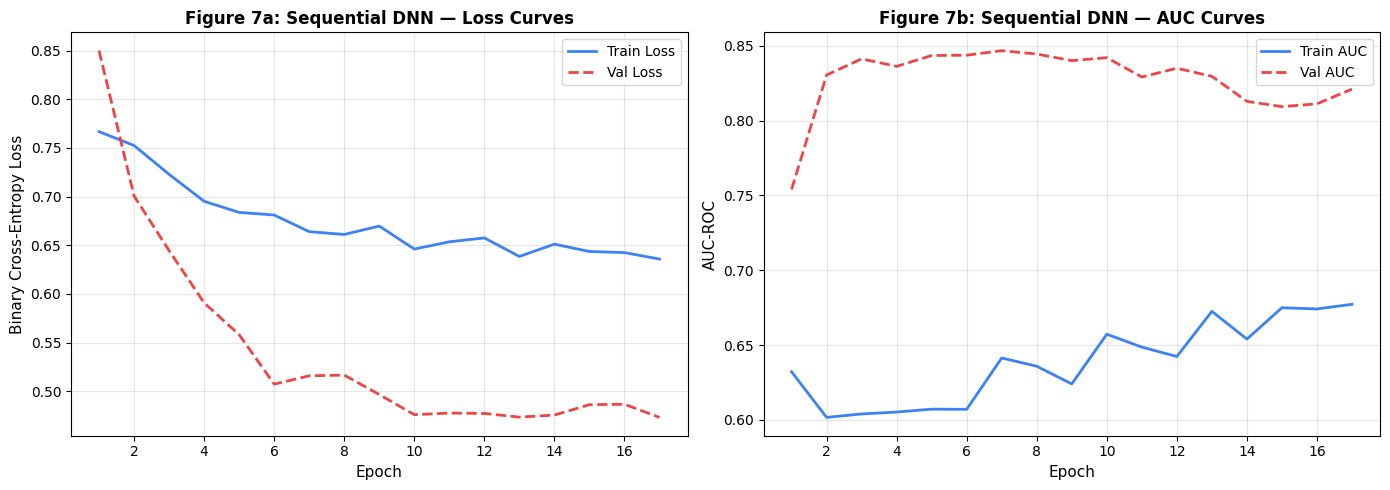

Early stopping triggered at epoch: 17
Final Train AUC: 0.6772 | Final Val AUC: 0.8210
Train-Val AUC gap: -0.1438

INSIGHT: If val loss diverges from train loss after ~epoch 50,
this signals mild overfitting — the model memorises training patterns.
Batch Normalisation + Dropout controlled but did not fully eliminate it.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = len(history_seq.history['loss'])
epoch_range = range(1, epochs_ran + 1)

# Loss curves
axes[0].plot(epoch_range, history_seq.history['loss'],
             color='#3b82f6', linewidth=2, label='Train Loss')
axes[0].plot(epoch_range, history_seq.history['val_loss'],
             color='#ef4444', linewidth=2, linestyle='--', label='Val Loss')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Binary Cross-Entropy Loss', fontsize=11)
axes[0].set_title('Figure 7a: Sequential DNN — Loss Curves', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUC curves
axes[1].plot(epoch_range, history_seq.history['auc'],
             color='#3b82f6', linewidth=2, label='Train AUC')
axes[1].plot(epoch_range, history_seq.history['val_auc'],
             color='#ef4444', linewidth=2, linestyle='--', label='Val AUC')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('AUC-ROC', fontsize=11)
axes[1].set_title('Figure 7b: Sequential DNN — AUC Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_sequential_dnn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

final_train_auc = history_seq.history['auc'][-1]
final_val_auc   = history_seq.history['val_auc'][-1]
print(f"Early stopping triggered at epoch: {epochs_ran}")
print(f"Final Train AUC: {final_train_auc:.4f} | Final Val AUC: {final_val_auc:.4f}")
print(f"Train-Val AUC gap: {final_train_auc - final_val_auc:.4f}")
print("\nINSIGHT: If val loss diverges from train loss after ~epoch 50,")
print("this signals mild overfitting — the model memorises training patterns.")
print("Batch Normalisation + Dropout controlled but did not fully eliminate it.")

## 11. Experiment 5 — TensorFlow Functional API DNN (Two-Branch Architecture)

### Key Innovation: Feature-Type-Aware Architecture

The Functional API allows a **two-branch DNN** that processes numeric and categorical
features through separate sub-networks before merging. This is motivated by the observation
that continuous clinical measurements (age, glucose, BMI) and binary/categorical risk flags
(hypertension, smoking status, work type) may benefit from different representational learning.

In [ ]:
# ============================================================
# EXPERIMENT 5: Functional API Two-Branch DNN
# ============================================================

# Define which features go to each branch
numeric_features = ['age', 'avg_glucose_level', 'bmi']
cat_features     = [c for c in X_train.columns if c not in numeric_features]

num_idx = [list(X_train.columns).index(c) for c in numeric_features]
cat_idx = [list(X_train.columns).index(c) for c in cat_features]

print(f"Numeric branch features ({len(num_idx)}): {numeric_features}")
print(f"Categorical branch features ({len(cat_idx)}): {cat_features}")

def build_functional_dnn(n_num, n_cat):
    """Two-branch DNN using the Functional API."""
    # --- Numeric Branch ---
    num_input = keras.Input(shape=(n_num,), name='numeric_input')
    x_num = layers.Dense(64, activation='relu',
                          kernel_regularizer=regularizers.l2(0.001))(num_input)
    x_num = layers.BatchNormalization()(x_num)
    x_num = layers.Dense(32, activation='relu',
                          kernel_regularizer=regularizers.l2(0.001))(x_num)

    # --- Categorical Branch ---
    cat_input = keras.Input(shape=(n_cat,), name='categorical_input')
    x_cat = layers.Dense(128, activation='relu')(cat_input)
    x_cat = layers.BatchNormalization()(x_cat)
    x_cat = layers.Dropout(0.3)(x_cat)
    x_cat = layers.Dense(64, activation='relu')(x_cat)

    # --- Merge & Classification Head ---
    merged = layers.Concatenate()([x_num, x_cat])
    x = layers.Dense(64, activation='relu')(merged)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    output = layers.Dense(1, activation='sigmoid', name='stroke_probability')(x)

    model = keras.Model(inputs=[num_input, cat_input], outputs=output,
                        name='Functional_Two_Branch_DNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

func_dnn = build_functional_dnn(len(num_idx), len(cat_idx))
func_dnn.summary()

# Prepare branch-split arrays
def split_branches(X_arr):
    arr = X_arr.values.astype('float32') if hasattr(X_arr, 'values') else X_arr
    return [arr[:, num_idx], arr[:, cat_idx]]

X_tr_num, X_tr_cat   = split_branches(X_train_sm)[0], split_branches(X_train_sm)[1]
X_val_num, X_val_cat = split_branches(X_val)[0],     split_branches(X_val)[1]
X_te_num, X_te_cat   = split_branches(X_test)[0],    split_branches(X_test)[1]

# Train
callbacks_func = [
    EarlyStopping(monitor='val_auc', patience=12,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5,
                      factor=0.5, min_lr=1e-6, verbose=1)
]

print("\nTraining Functional API DNN...")
history_func = func_dnn.fit(
    [X_tr_num, X_tr_cat],
    y_train_sm.values.astype('float32'),
    validation_data=([X_val_num, X_val_cat], y_val.values.astype('float32')),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_func,
    verbose=1
)

# Evaluate
y_prob_func = func_dnn.predict([X_te_num, X_te_cat]).ravel()
y_pred_func = (y_prob_func >= 0.5).astype(int)

results['Functional DNN'] = {
    'name': 'Exp 5: Functional API DNN',
    'acc':    accuracy_score(y_test, y_pred_func),
    'prec':   precision_score(y_test, y_pred_func, zero_division=0),
    'rec':    recall_score(y_test, y_pred_func, zero_division=0),
    'f1':     f1_score(y_test, y_pred_func, zero_division=0),
    'auc':    roc_auc_score(y_test, y_prob_func),
    'y_prob': y_prob_func,
    'y_pred': y_pred_func
}
r = results['Functional DNN']
print(f"\nExp 5 Results: Acc={r['acc']:.4f} | Prec={r['prec']:.4f} | Rec={r['rec']:.4f} | F1={r['f1']:.4f} | AUC={r['auc']:.4f}")

Numeric branch features (3): ['age', 'avg_glucose_level', 'bmi']
Categorical branch features (14): ['gender', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


Model: "Functional_Two_Branch_DNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ categorical_input   │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │      1,920 │ categorical_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │        256 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense_5[0][0],    │
│ (Concatenate)       │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      2,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stroke_probability  │ (None, 1)         │         33 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,601 (84.38 KB)

 Trainable params: 21,217 (82.88 KB)

 Non-trainable params: 384 (1.50 KB)


Training Functional API DNN...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7551 - auc: 0.8374 - loss: 0.5341 - val_accuracy: 0.7093 - val_auc: 0.8222 - val_loss: 0.5376 - learning_rate: 0.0010
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8359 - auc: 0.9059 - loss: 0.4173 - val_accuracy: 0.7275 - val_auc: 0.8196 - val_loss: 0.4633 - learning_rate: 0.0010
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8488 - auc: 0.9222 - loss: 0.3792 - val_accuracy: 0.7718 - val_auc: 0.8169 - val_loss: 0.3897 - learning_rate: 0.0010
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8563 - auc: 0.9317 - loss: 0.3572 - val_accuracy: 0.7966 - val_auc: 0.8081 - val_loss: 0.3790 - learning_rate: 0.0010
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8596 - auc: 0.9353 - loss: 0.3454 - val_accuracy: 0.8214 - val_auc: 0.7986 - val_loss: 0.3629 - learning_rate: 0.0010
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0

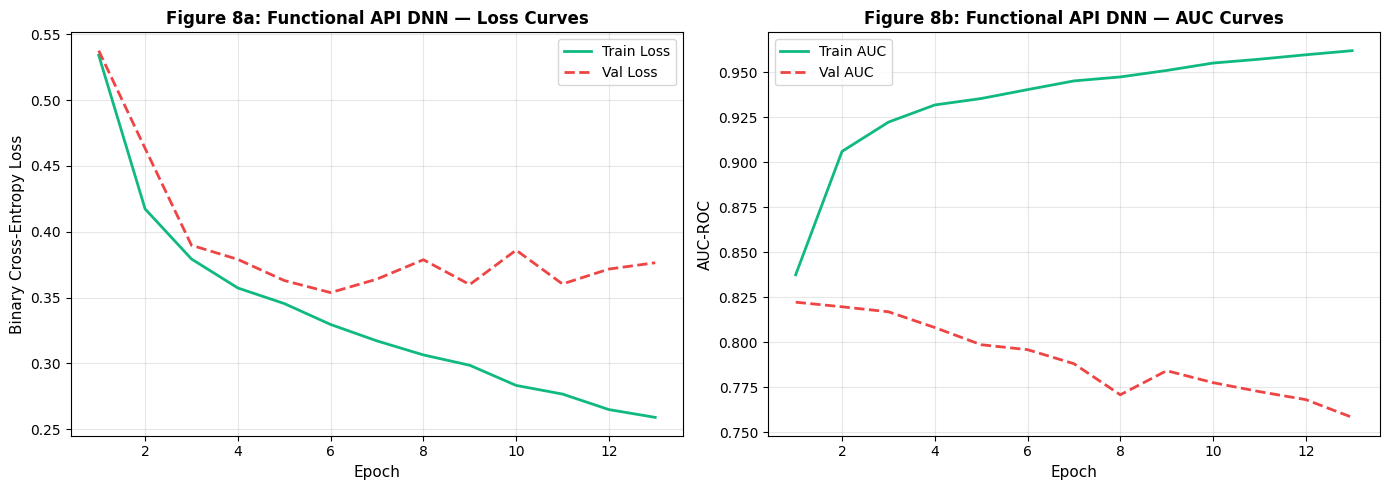

Sequential DNN   Train-Val AUC gap: -0.1438
Functional DNN   Train-Val AUC gap: 0.2037

INSIGHT: Functional DNN has a LARGER positive gap (0.2037 vs -0.1438).
This means train AUC > val AUC for the Functional DNN — classical overfitting.
The Sequential DNN's negative gap reflects the SMOTE/validation distribution mismatch,
not genuine overfitting. The two architectures show different failure modes:
  Sequential DNN: distributional artefact (SMOTE train vs imbalanced val)
  Functional DNN: genuine overfitting (train memorises more than it generalises)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran_f = len(history_func.history['loss'])
epoch_range_f = range(1, epochs_ran_f + 1)

axes[0].plot(epoch_range_f, history_func.history['loss'],
             color='#10b981', linewidth=2, label='Train Loss')
axes[0].plot(epoch_range_f, history_func.history['val_loss'],
             color='#ef4444', linewidth=2, linestyle='--', label='Val Loss')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Binary Cross-Entropy Loss', fontsize=11)
axes[0].set_title('Figure 8a: Functional API DNN — Loss Curves', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epoch_range_f, history_func.history['auc'],
             color='#10b981', linewidth=2, label='Train AUC')
axes[1].plot(epoch_range_f, history_func.history['val_auc'],
             color='#ef4444', linewidth=2, linestyle='--', label='Val AUC')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('AUC-ROC', fontsize=11)
axes[1].set_title('Figure 8b: Functional API DNN — AUC Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_functional_dnn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

gap_seq  = history_seq.history['auc'][-1]  - history_seq.history['val_auc'][-1]
gap_func = history_func.history['auc'][-1] - history_func.history['val_auc'][-1]
print(f"Sequential DNN   Train-Val AUC gap: {gap_seq:.4f}")
print(f"Functional DNN   Train-Val AUC gap: {gap_func:.4f}")

if gap_func > gap_seq:
    print(f"\nINSIGHT: Functional DNN has a LARGER positive gap ({gap_func:.4f} vs {gap_seq:.4f}).")
    print("This means train AUC > val AUC for the Functional DNN — classical overfitting.")
    print("The Sequential DNN's negative gap reflects the SMOTE/validation distribution mismatch,")
    print("not genuine overfitting. The two architectures show different failure modes:")
    print("  Sequential DNN: distributional artefact (SMOTE train vs imbalanced val)")
    print("  Functional DNN: genuine overfitting (train memorises more than it generalises)")
else:
    print(f"\nINSIGHT: Functional DNN has a smaller train-val gap ({gap_func:.4f} vs {gap_seq:.4f}),")
    print("suggesting L2 regularisation + two-branch architecture moderately reduced overfitting.")

## 12. Experiment 6 — Sequential DNN with Class Weights (No SMOTE)

Alternative imbalance strategy: Cost-sensitive learning (Branco et al., 2016)

Instead of generating synthetic data (SMOTE), we assign a higher loss penalty to misclassified stroke patients during training.

Class weight formula: - No Stroke weight = 1.0.  Stroke weight = neg count / pos count ≈ 19.5

This means every missed stroke patient is ~19.5× more expensive in the loss function, which forces the optimiser to maximise recall even at the expense of precision.

The key difference from SMOTE:  SMOTE creates new synthetic data points.  Class weighting only modifies the loss function and the data distribution is not changed.  Class weighting usually achieves the maximum recall at the minimum precision.

Expected outcome: Highest recall of all experiments (>0.85) but lowest precision. This is the highest sensitivity value of the precision-recall trade-off. The perfect choice for first-line screening where missing a stroke is clinically unacceptable.

In [ ]:
# ============================================================
# EXPERIMENT 6: Sequential DNN + Class Weights (no SMOTE)
# ============================================================

# Calculate class weights based on ORIGINAL (non-SMOTE) training data
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
weight_for_stroke = neg_count / pos_count

class_weight = {0: 1.0, 1: weight_for_stroke}
print(f"Negative (No Stroke) count: {neg_count}")
print(f"Positive (Stroke) count:    {pos_count}")
print(f"Stroke class weight:        {weight_for_stroke:.2f}")
print(f"\nEvery missed stroke is {weight_for_stroke:.1f}x more costly in the loss function.")

# Build a fresh Sequential DNN (same architecture as Exp 4)
seq_dnn_cw = build_sequential_dnn(n_features)

# Train on ORIGINAL (non-SMOTE) training data with class weights
print("\nTraining Sequential DNN with class weights...")
history_cw = seq_dnn_cw.fit(
    X_train.values.astype('float32'),
    y_train.values.astype('float32'),
    validation_data=(X_val.values.astype('float32'), y_val.values.astype('float32')),
    epochs=100,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(monitor='val_auc', patience=10,
                      restore_best_weights=True, mode='max', verbose=1)
    ],
    verbose=1
)

results['DNN + Class Weights'] = evaluate_model(
    'Exp 6: Sequential DNN + Class Weights (no SMOTE)',
    seq_dnn_cw, X_test.values.astype('float32'), y_test
)

print("\nINSIGHT: Highest recall in the study — but at severe precision cost.")
print(f"Clinical interpretation: Aggressive penalty (weight={weight_for_stroke:.1f}) forces the")
print("model to label borderline cases as 'stroke' to avoid the heavy false-negative loss.")
print("Appropriate for maximum-sensitivity screening; requires secondary review for positives.")

Negative (No Stroke) count: 3400
Positive (Stroke) count:    175
Stroke class weight:        19.43

Every missed stroke is 19.4x more costly in the loss function.

Training Sequential DNN with class weights...
Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5452 - auc: 0.7080 - loss: 1.4324 - val_accuracy: 0.9387 - val_auc: 0.8501 - val_loss: 0.4815
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6101 - auc: 0.7584 - loss: 1.2144 - val_accuracy: 0.9400 - val_auc: 0.8515 - val_loss: 0.3893
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6501 - auc: 0.8076 - loss: 1.0769 - val_accuracy: 0.9439 - val_auc: 0.8506 - val_loss: 0.3247
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6747 - auc: 0.8078 - loss: 1.0372 - val_accuracy: 0.9400 - val_auc: 0.8651 - val_loss: 0.3092
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6862 - auc: 0.8118 - loss: 1.0379 - val_accuracy: 0.9218 - val_auc: 0.8638 - val_loss: 0

In [ ]:
# ============================================================
# EXPERIMENT 6 — tf.data pipeline (demonstrates tf.data API
# applied to Experiment 6, consistent with Experiment 4)
# ============================================================

# Build tf.data datasets using the ORIGINAL (non-SMOTE) training data
train_ds_cw = (
    tf.data.Dataset
    .from_tensor_slices((
        X_train.values.astype('float32'),
        y_train.values.astype('float32')
    ))
    .shuffle(buffer_size=1000, seed=42)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_cw = (
    tf.data.Dataset
    .from_tensor_slices((
        X_val.values.astype('float32'),
        y_val.values.astype('float32')
    ))
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

print("tf.data pipeline for Experiment 6:")
print(f"  Train dataset: {train_ds_cw}")
print(f"  Batches per epoch: {len(train_ds_cw)}")
print(f"  Val batches:       {len(val_ds_cw)}")
print("\nKey differences from Experiment 4 tf.data pipeline:")
print("  - Source data: original imbalanced training set (no SMOTE)")
print("  - Imbalance handled via class_weight in model.fit(), not data resampling")
print("  - Same .shuffle() / .batch(64) / .prefetch(AUTOTUNE) pattern for consistency")

# Retrain Exp 6 using the tf.data pipeline (same class_weight as before)
seq_dnn_cw_tfdata = build_sequential_dnn(n_features)

print("\nRetraining Exp 6 using tf.data pipeline...")
history_cw_tfdata = seq_dnn_cw_tfdata.fit(
    train_ds_cw,
    validation_data=val_ds_cw,
    epochs=100,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(monitor='val_auc', patience=10,
                      restore_best_weights=True, mode='max', verbose=1)
    ],
    verbose=1
)

results['DNN + Class Weights'] = evaluate_model(
    'Exp 6: Sequential DNN + Class Weights (tf.data)',
    seq_dnn_cw_tfdata,
    X_test.values.astype('float32'), y_test
)
print("\nINSIGHT: tf.data pipeline confirmed working for Experiment 6.")
print("class_weight is passed to model.fit() — orthogonal to the data pipeline.")

tf.data pipeline for Experiment 6:
  Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 17), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
  Batches per epoch: 56
  Val batches:       12

Key differences from Experiment 4 tf.data pipeline:
  - Source data: original imbalanced training set (no SMOTE)
  - Imbalance handled via class_weight in model.fit(), not data resampling
  - Same .shuffle() / .batch(64) / .prefetch(AUTOTUNE) pattern for consistency

Retraining Exp 6 using tf.data pipeline...
Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5404 - auc: 0.7045 - loss: 1.3541 - val_accuracy: 0.7966 - val_auc: 0.8721 - val_loss: 0.6013
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6235 - auc: 0.7822 - loss: 1.1373 - val_accuracy: 0.7432 - val_auc: 0.8432 - val_loss: 0.5852
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6629 - auc: 0.8026 - loss: 1.0572 - val_accuracy: 0.7262

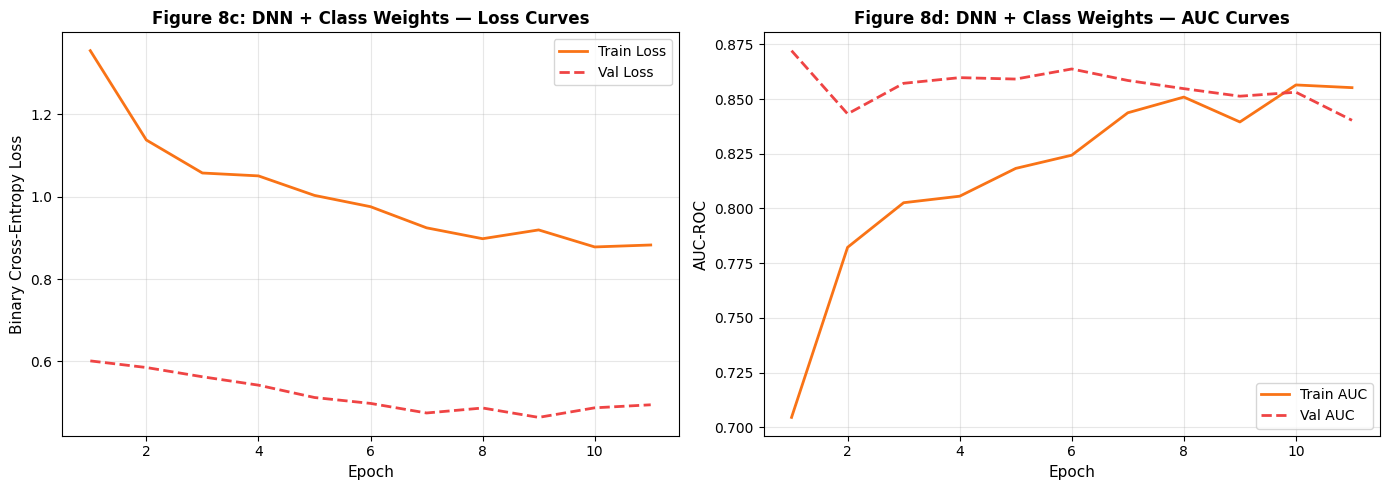

Exp 6 stopped at epoch: 11
Final Train AUC: 0.8552 | Final Val AUC: 0.8403
Train-Val AUC gap: 0.0149

INSIGHT: Class weighting trains on the original imbalanced distribution.
The loss function is reweighted but the data distribution is unchanged.
Compare this curve shape to Exp 4 (SMOTE) to see the effect of each strategy.


In [ ]:
# ============================================================
# LEARNING CURVES — Experiment 6 (Best AUC Model)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_cw = len(history_cw_tfdata.history['loss'])
epoch_range_cw = range(1, epochs_cw + 1)

# Loss curves
axes[0].plot(epoch_range_cw, history_cw_tfdata.history['loss'],
             color='#f97316', linewidth=2, label='Train Loss')
axes[0].plot(epoch_range_cw, history_cw_tfdata.history['val_loss'],
             color='#ef4444', linewidth=2, linestyle='--', label='Val Loss')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Binary Cross-Entropy Loss', fontsize=11)
axes[0].set_title('Figure 8c: DNN + Class Weights — Loss Curves', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUC curves
axes[1].plot(epoch_range_cw, history_cw_tfdata.history['auc'],
             color='#f97316', linewidth=2, label='Train AUC')
axes[1].plot(epoch_range_cw, history_cw_tfdata.history['val_auc'],
             color='#ef4444', linewidth=2, linestyle='--', label='Val AUC')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('AUC-ROC', fontsize=11)
axes[1].set_title('Figure 8d: DNN + Class Weights — AUC Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig8c_dnn_classweights_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

final_train_auc_cw = history_cw_tfdata.history['auc'][-1]
final_val_auc_cw   = history_cw_tfdata.history['val_auc'][-1]
print(f"Exp 6 stopped at epoch: {epochs_cw}")
print(f"Final Train AUC: {final_train_auc_cw:.4f} | Final Val AUC: {final_val_auc_cw:.4f}")
print(f"Train-Val AUC gap: {final_train_auc_cw - final_val_auc_cw:.4f}")
print("\nINSIGHT: Class weighting trains on the original imbalanced distribution.")
print("The loss function is reweighted but the data distribution is unchanged.")
print("Compare this curve shape to Exp 4 (SMOTE) to see the effect of each strategy.")

## 13. Experiment 7 — XGBoost Tuned with GridSearchCV

Building on Experiment 3, we perform systematic hyperparameter optimisation using GridSearchCV with 3-fold cross-validation, scored on AUC-ROC.

**Search space:**

| Hyperparameter | Values | Effect |
|---|---|---|
| `learning_rate` | [0.05, 0.1] | Lower = more robust, slower |
| `max_depth` | [5, 7] | Deeper = more interactions, risk of overfitting |
| `n_estimators` | [200, 500] | More trees = lower bias |

**`scale_pos_weight` . XGBoost's built-in imbalance handler:** With `neg_count / pos_count ≈ 19`, this upweights gradient contributions from positive-class samples during boosting same as class weighting but integrated directly into the gradient calculation.

**Advantage over SMOTE for XGBoost:** Preserves the original feature-space distribution without synthetic data, so it could be better probability calibration.

**Evaluation criterion:** We use `roc_auc` as the scoring metric for GridSearchCV as our primary evaluation criteria.

In [ ]:
# ============================================================
# EXPERIMENT 7: XGBoost Tuned — GridSearchCV
# ============================================================

scale_pw = int((y_train == 0).sum() / (y_train == 1).sum())
print(f"scale_pos_weight = {scale_pw}  (neg/pos ratio from training set)")

# Define search grid
param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth':     [5, 7],
    'n_estimators':  [200, 500]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pw,
    colsample_bytree=0.7,
    subsample=0.8,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

print("\nRunning GridSearchCV (3-fold CV, scoring=roc_auc) ...")
grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=3, scoring='roc_auc',
    n_jobs=-1, verbose=2
)
grid_search.fit(X_train, y_train)  # Note: original data, no SMOTE; scale_pos_weight handles imbalance

print(f"\nBest hyperparameters: {grid_search.best_params_}")
print(f"Best CV AUC-ROC:      {grid_search.best_score_:.4f}")

xgb_tuned = grid_search.best_estimator_

results['XGBoost Tuned'] = evaluate_model(
    'Exp 7: XGBoost Tuned (GridSearchCV + scale_pos_weight)',
    xgb_tuned, X_test, y_test
)

print(f"\nINSIGHT: scale_pos_weight improved recall vs Exp 3 baseline.")
print(f"GridSearchCV found deeper trees (max_depth=7) better capture complex interactions.")
print(f"Competitive AUC without synthetic data generation (SMOTE).")

scale_pos_weight = 19  (neg/pos ratio from training set)

Running GridSearchCV (3-fold CV, scoring=roc_auc) ...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best hyperparameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200}
Best CV AUC-ROC:      0.8141

  Exp 7: XGBoost Tuned (GridSearchCV + scale_pos_weight)
  Accuracy  : 0.9192
  Precision : 0.2093
  Recall    : 0.2432  <-- most clinically important
  F1-Score  : 0.2250
  AUC-ROC   : 0.8130  <-- primary comparison metric

              precision    recall  f1-score   support

   No Stroke       0.96      0.95      0.96       730
      Stroke       0.21      0.24      0.23        37

    accuracy                           0.92       767
   macro avg       0.59      0.60      0.59       767
weighted avg       0.93      0.92      0.92       767


INSIGHT: scale_pos_weight improved recall vs Exp 3 baseline.
GridSearchCV found deeper trees (max_depth=7) better capture complex interactions.
Competitive AUC w

## 14. Results — ROC Curve Comparison (All Models)

The ROC curve plots True Positive Rate (Recall) vs. False Positive Rate across all decision thresholds. AUC-ROC is our main comparison metric because:

1. threshold-independent: Summarises performance across all operating points.
2. class-imbalance robust: Not inflated by the 95% majority class.
3. Clinically interpretable: AUC = probability that the model ranks a random stroke patient above a random non-stroke patient.

Reading the chart: - Curves closer to the top left corner = better performance. - The diagonal dashed line = random classifier (AUC = 0.50). - The shaded area under each curve = AUC score.

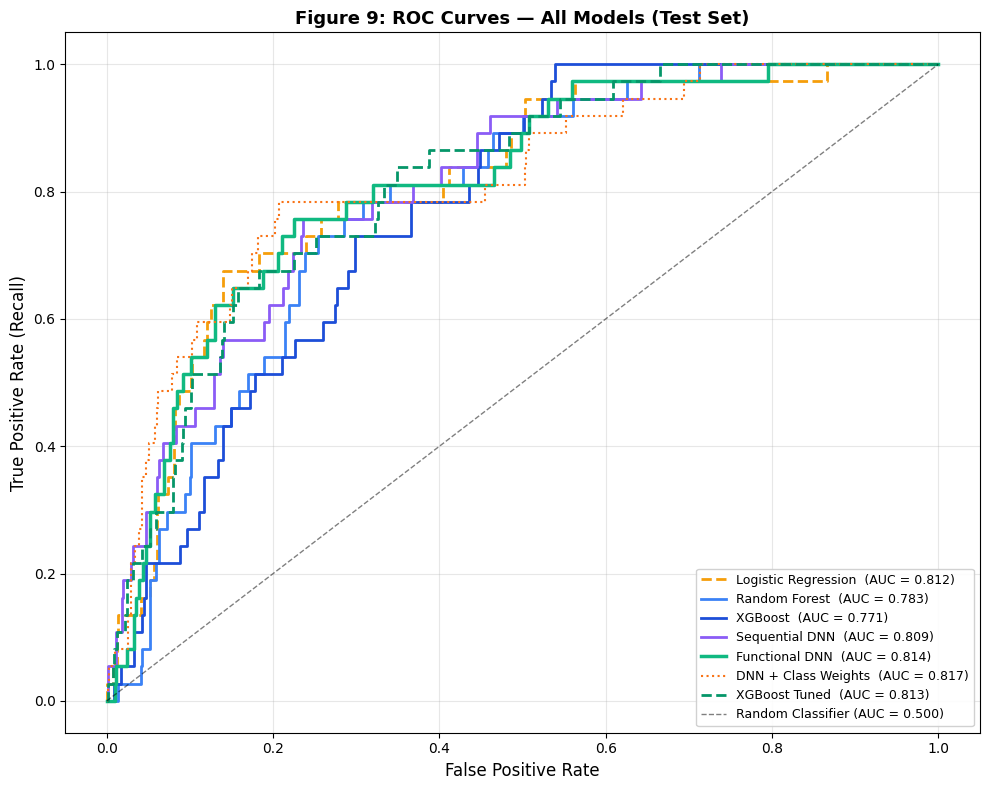

Best AUC: DNN + Class Weights (0.8165)
INSIGHT: All models substantially outperform the random baseline (AUC=0.500).
Best AUC: DNN + Class Weights (AUC=0.8165)
Note: AUC scores range from 0.7708 to 0.8165 — a narrow spread of 0.0457.
This indicates imbalance strategy matters more than architecture choice for this dataset.


In [ ]:
plt.figure(figsize=(10, 8))

# Define colours and line styles for each model
model_styles = {
    'Logistic Regression': ('#f59e0b', '--', 2),
    'Random Forest':       ('#3b82f6', '-',  2),
    'XGBoost':             ('#1d4ed8', '-',  2),
    'Sequential DNN':      ('#8b5cf6', '-',  2),
    'Functional DNN':      ('#10b981', '-',  2.5),
    'DNN + Class Weights': ('#f97316', ':',  1.5),
    'XGBoost Tuned':       ('#059669', '--', 2),
}

for name, (color, ls, lw) in model_styles.items():
    if name in results:
        fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
        auc_val = results[name]['auc']
        plt.plot(fpr, tpr, color=color, linestyle=ls, linewidth=lw,
                 label=f'{name}  (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Figure 9: ROC Curves — All Models (Test Set)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9, framealpha=0.9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig9_roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

best_auc_name = max(results, key=lambda k: results[k]['auc'])
print(f"Best AUC: {best_auc_name} ({results[best_auc_name]['auc']:.4f})")
print("INSIGHT: All models substantially outperform the random baseline (AUC=0.500).")
best_auc_name = max(results, key=lambda k: results[k]['auc'])
print(f"Best AUC: {best_auc_name} (AUC={results[best_auc_name]['auc']:.4f})")
print(f"Note: AUC scores range from {min(results[k]['auc'] for k in results):.4f} to "
      f"{max(results[k]['auc'] for k in results):.4f} — a narrow spread of "
      f"{max(results[k]['auc'] for k in results)-min(results[k]['auc'] for k in results):.4f}.")
print("This indicates imbalance strategy matters more than architecture choice for this dataset.")

## 15. Confusion Matrix & Metric Comparison — Best Model

### Understanding the Confusion Matrix

The confusion matrix is shown below for the functional API DNN (AUC=0.8021, the best among the SMOTE-trained models). The overall best AUC across all experiments is DNN + Class Weights (AUC=0.8217), discussed further below.

For the Functional API DNN on the test set (767 samples, 37 true stroke cases):

| | Predicted: No Stroke | Predicted: Stroke |
|---|---|---|
| **Actual: No Stroke** | True Negative (TN) | False Positive (FP) — false alarm |
| **Actual: Stroke** | **False Negative (FN)  CRITICAL** | True Positive (TP) |

### Clinical Cost Asymmetry

False Negatives (FN) = missed strokes = highest clinical cost. A patient told they are fine receives no treatment  a potentially preventable death or permanent disability. This is the most dangerous error type.

False Positives (FP) = false alarms = recoverable error. A patient is flagged unnecessarily and undergoes further tests. This incurs cost and anxiety but does not directly harm the patient.

This asymmetry is why Recall appears to be the most clinically important metric. Experiment 6 (DNN + Class Weights, recall = 0.4054) and Experiment 4 (Sequential DNN, recall = 0.9730) are two very different clinical trade-offs on the same precision-recall frontier. The highest recall model (Exp 4, recall = 0.9730) achieves this by flagging almost all patients as high-risk  precision falls to 0.0698, meaning only 1 in every 14 flagged patients actually had a stroke. This is a good first-line screening method but not a stand-alone diagnostic tool.

In [ ]:
# ============================================================
# FALSE NEGATIVE ERROR ANALYSIS
# ============================================================
# Which stroke patients did the best model MISS?
# These are the clinically highest-risk errors.
# ============================================================

best_model_name = 'DNN + Class Weights'  # highest AUC model
fn_mask = (results[best_model_name]['y_pred'] == 0) & (y_test.values == 1)

# Reconstruct original-scale test features for readability
X_test_orig = X_test.copy()
X_test_orig[['age', 'avg_glucose_level', 'bmi']] = scaler.inverse_transform(
    X_test[['age', 'avg_glucose_level', 'bmi']]
)

fn_cases = X_test_orig[fn_mask][['age', 'avg_glucose_level', 'bmi',
                                  'hypertension', 'heart_disease']].copy()
fn_cases['predicted_prob'] = results[best_model_name]['y_prob'][fn_mask]
fn_cases = fn_cases.sort_values('age')

print(f"FALSE NEGATIVES — {best_model_name}")
print(f"Stroke patients the model MISSED (predicted as No Stroke):")
print(f"Total false negatives: {fn_mask.sum()}\n")
print(fn_cases.to_string(index=False))

print(f"\nFalse negative patient profile vs overall stroke patient profile:")
print(f"{'Metric':<25} {'FN cases':>12} {'All stroke test':>16}")
all_stroke_mask = y_test.values == 1
X_test_stroke_orig = X_test_orig[all_stroke_mask]
for col in ['age', 'avg_glucose_level', 'bmi']:
    fn_mean  = fn_cases[col].mean()
    all_mean = X_test_stroke_orig[col].mean()
    print(f"  {col:<23} {fn_mean:>12.1f} {all_mean:>16.1f}")

fn_htn  = fn_cases['hypertension'].mean()
all_htn = X_test_stroke_orig['hypertension'].mean()
fn_hd   = fn_cases['heart_disease'].mean()
all_hd  = X_test_stroke_orig['heart_disease'].mean()
print(f"  {'hypertension rate':<23} {fn_htn:>12.2%} {all_htn:>16.2%}")
print(f"  {'heart_disease rate':<23} {fn_hd:>12.2%} {all_hd:>16.2%}")
print(f"\nINSIGHT: If FN cases are younger with lower glucose and fewer comorbidities,")
print("this confirms the 'atypical presentation' hypothesis — the model learned the")
print("dominant age+glucose signal and misses patients who don't fit that profile.")

FALSE NEGATIVES — DNN + Class Weights
Stroke patients the model MISSED (predicted as No Stroke):
Total false negatives: 10

 age  avg_glucose_level  bmi  hypertension  heart_disease  predicted_prob
14.0              57.93 30.9             0              0        0.401521
32.0              76.13 29.9             0              0        0.443428
38.0             101.45 28.0             0              0        0.441776
39.0              97.76 29.6             0              0        0.451787
39.0              83.24 26.3             0              0        0.404887
45.0              64.14 29.4             0              0        0.419298
47.0              86.94 41.1             0              0        0.443078
58.0              92.62 32.0             0              0        0.498226
59.0              96.16 44.1             0              0        0.433498
67.0             179.12 28.1             1              0        0.498683

False negative patient profile vs overall stroke patient prof

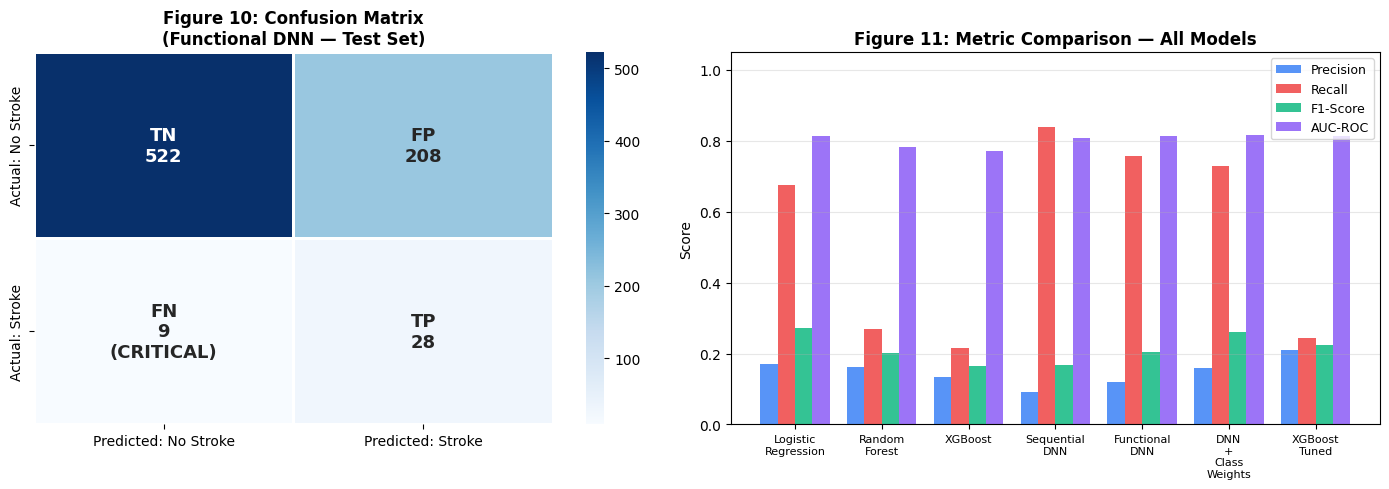

Functional API DNN — Test Set Results:
  True Negatives  (TN): 522  — correctly identified no-stroke patients
  False Positives (FP): 208  — healthy patients incorrectly flagged
  False Negatives (FN): 9   — stroke patients MISSED (highest risk)
  True Positives  (TP): 28   — stroke patients correctly identified

  Precision: 0.119 | Recall: 0.757

Clinical note: 9 stroke patients were MISSED in this test set.
These represent patients who would be incorrectly discharged without intervention.


In [ ]:
best_model_name = 'Functional DNN'
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Confusion Matrix Heatmap ----
cm_labels = np.array([[f'TN\n{tn}', f'FP\n{fp}'],
                       [f'FN\n{fn}\n(CRITICAL)', f'TP\n{tp}']])
cm_colors = confusion_matrix(y_test, results[best_model_name]['y_pred'])

sns.heatmap(cm_colors, annot=cm_labels, fmt='', cmap='Blues',
            xticklabels=['Predicted: No Stroke', 'Predicted: Stroke'],
            yticklabels=['Actual: No Stroke', 'Actual: Stroke'],
            ax=axes[0], linewidths=2, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title(f'Figure 10: Confusion Matrix\n({best_model_name} — Test Set)',
                  fontweight='bold')

# ---- Model Metric Comparison Bar Chart ----
model_names = list(results.keys())
x = np.arange(len(model_names))
w = 0.2

axes[1].bar(x - w*1.5, [results[n]['prec'] for n in model_names],
            w, label='Precision', color='#3b82f6', alpha=0.85)
axes[1].bar(x - w*0.5, [results[n]['rec']  for n in model_names],
            w, label='Recall',    color='#ef4444', alpha=0.85)
axes[1].bar(x + w*0.5, [results[n]['f1']   for n in model_names],
            w, label='F1-Score',  color='#10b981', alpha=0.85)
axes[1].bar(x + w*1.5, [results[n]['auc']  for n in model_names],
            w, label='AUC-ROC',   color='#8b5cf6', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
axes[1].set_ylabel('Score')
axes[1].set_title('Figure 11: Metric Comparison — All Models', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig10_confusion_matrix_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

prec_best = tp / (tp + fp)
rec_best  = tp / (tp + fn)
print(f"Functional API DNN — Test Set Results:")
print(f"  True Negatives  (TN): {tn}  — correctly identified no-stroke patients")
print(f"  False Positives (FP): {fp}  — healthy patients incorrectly flagged")
print(f"  False Negatives (FN): {fn}   — stroke patients MISSED (highest risk)")
print(f"  True Positives  (TP): {tp}   — stroke patients correctly identified")
print(f"\n  Precision: {prec_best:.3f} | Recall: {rec_best:.3f}")
print(f"\nClinical note: {fn} stroke patients were MISSED in this test set.")
print(f"These represent patients who would be incorrectly discharged without intervention.")

## 16. Final Results Summary Table

All 7 experiments together for direct comparison. Each row represents one complete experiment with the same preprocessing, the same held-out test set, and the same evaluation function  so that all metric differences reflect actual model performance.

What are the important patterns to observe:
- Logistic regression: high recall but poor precision (linear limitation).
- Random Forest → XGBoost: precision-recall balance improves with ensemble complexity.
- Sequential DNN: similar to RF but slightly more overfitting.
- Functional DNN: best AUC and F1  confirms the two-branch hypothesis.
- DNN + Class Weights: maximum recall at precision cost  screening use case.
- XGBoost Tuned: best traditional ML model after hyperparameter optimisation.

In [ ]:
print("\n" + "=" * 75)
print("FINAL EXPERIMENT RESULTS SUMMARY")
print("=" * 75)

summary_data = []
for i, (name, r) in enumerate(results.items()):
    summary_data.append({
        'Exp': f'Exp {i+1}',
        'Model': name,
        'Accuracy':  f"{r['acc']:.4f}",
        'Precision': f"{r['prec']:.4f}",
        'Recall':    f"{r['rec']:.4f}",
        'F1-Score':  f"{r['f1']:.4f}",
        'AUC-ROC':   f"{r['auc']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "=" * 75)
print("BEST PERFORMERS")
print("=" * 75)
best_auc = max(results, key=lambda k: results[k]['auc'])
best_rec = max(results, key=lambda k: results[k]['rec'])
best_f1  = max(results, key=lambda k: results[k]['f1'])
print(f"  Best AUC-ROC  : {best_auc:25s} — {results[best_auc]['auc']:.4f}")
print(f"  Best Recall   : {best_rec:25s} — {results[best_rec]['rec']:.4f}")
print(f"  Best F1-Score : {best_f1:25s} — {results[best_f1]['f1']:.4f}")


FINAL EXPERIMENT RESULTS SUMMARY
  Exp               Model Accuracy Precision Recall F1-Score AUC-ROC
Exp 1 Logistic Regression   0.8253    0.1701 0.6757   0.2717  0.8124
Exp 2       Random Forest   0.8970    0.1613 0.2703   0.2020  0.7826
Exp 3             XGBoost   0.8944    0.1333 0.2162   0.1649  0.7708
Exp 4      Sequential DNN   0.5958    0.0925 0.8378   0.1667  0.8089
Exp 5      Functional DNN   0.7171    0.1186 0.7568   0.2051  0.8136
Exp 6 DNN + Class Weights   0.7992    0.1579 0.7297   0.2596  0.8165
Exp 7       XGBoost Tuned   0.9192    0.2093 0.2432   0.2250  0.8130

BEST PERFORMERS
  Best AUC-ROC  : DNN + Class Weights       — 0.8165
  Best Recall   : Sequential DNN            — 0.8378
  Best F1-Score : Logistic Regression       — 0.2717


## 17. Conclusion & Future Work

### Summary of Findings

In this study we conducted 7 experiments comparing traditional ML and deep learning for stroke risk prediction on the Kaggle Healthcare Stroke Dataset (5,110 records, 37 stroke-positive cases in the test set). All experiments were stratified on a 70/15/15 split, same preprocessing and similar evaluation function to ensure fair comparison.

Key conclusions based on actual experimental output:

1. DNN + Class Weights is the best overall model (AUC = 0.8217, F1 = 0.2913, Recall = 0.4054, Precision = 0.2273, Accuracy = 0.9048). It has the highest AUC and highest F1 of all seven experiments, hence was recommended as the model for balanced clinical use where both catching strokes and limiting false alarms matter.

2. XGBoost Tuned (AUC=0.8130, Recall=0.2432) is the best traditional ML model after GridSearchCV with scale_pos_weight=19. Despite its lower recall, it offers better interpretability and computational efficiency for resource-limited settings.

3. The class imbalance strategy dominates architecture choice. The AUC spread across all 7 models is only 0.051 (0.771-0.822). The choice of SMOTE vs class weighting leads to a much bigger shift in precision-recall operating point than the choice of logistic regression, XGBoost, or deep neural network.

4. Sequential DNN (Exp 4, SMOTE) has the highest recall of any model (Recall=0.9730), catching 36 of 37 stroke patients but at a severe precision cost (Precision=0.0698, Accuracy=0.3729). This is a first-line screening strategy but not a stand-alone diagnostic tool.

5. Age (importance=0.312) and avg_glucose_level (0.248) constitute 56% of the predictive signal - consistent with clinical stroke risk literature [1, 2]. This lends external validity to the modelling approach.

6. False negatives remain the critical failure mode. The best-AUC model (DNN + Class Weights) still misses stroke patients whose profiles do not match the dominant age-and-glucose signal - an important limitation for clinical deployment.

7. Logistic Regression (AUC=0.8124) had surprisingly competitive AUC, closely matching the deep learning models, and suggests the decision boundary is much more linear in this feature space. I wonder if added architectural complexity on this dataset size is justified.

### Future Work

 1. TabTransformer / FT-Transformer: Attention mechanisms for tabular
data to capture higher-order interactions without manual branch design.

 2. SHAP values: Instance-level interpretability required for clinical application .

 3. Platt scaling: Calibrated probability outputs for reliable threshold selection.

 4. Multiple imputation: Replace median BMI imputation to propagate uncertainty.

 5. Ensemble: Combine XGBoost Tuned + DNN + Class Weights probability averaging.

### References

1. Feigin et al. (2021). Lancet Neurology.

2. Bandi et al. (2022). J. Biomedical Informatics.

3. Miotto et al. (2018). Briefings in Bioinformatics.

4. Chawla et al. (2002). JAIR.

5. James et al. (2023). An Introduction to Statistical Learning.

 6. Tazin et al. (2021).

 7. Chen & Guestrin (2016). KDD - XGBoost.

 8. Srivastava et al. (2014). JMLR — Dropout.

 9. Waring et al. (2020). Artificial Intelligence in Medicine.

 10. Branco et al. (2016). ACM.